# Are Used Electric Vehicles Priced Higher Than Gas Vehicles?

## Introduction

This notebook investigates whether used **electric vehicle (EV)** listings on Craigslist are priced higher than used **gas-powered vehicle** listings.

### Research Question
**Are used EV listings priced higher than used gas vehicle listings on Craigslist?**

### Hypotheses
- **Null Hypothesis (H₀):** There is no difference in listing price between EV and gas vehicles.
- **Alternative Hypothesis (H₁):** EV listings have *higher* prices than gas vehicle listings.

### Why use a Permutation Test + Bootstrap?

I will test the hypothesis **without** relying on any built-in statistical test function. Instead, I:
1. Use a **permutation test** to compute a p-value by randomly shuffling group labels and asking "how often does a random shuffle produce a difference as extreme as what was observed?"
2. Use **bootstrapping** to build a 95% confidence interval for the median price of EVs and for the median difference (EV − Gas).

I deliberately choose the **median** as the test statistic rather than the mean because:
- Car prices contain extreme outliers (very cheap or very expensive listings).
- The median is robust to outliers.
- The Central Limit Theorem (CLT) applies well to *means* of large samples, but **not as reliably to medians** — making bootstrapping the right tool for uncertainty estimation here.

### Dataset
This analysis uses the **Craigslist Used Cars dataset** provided as `car_listings.csv` — a local file in the project folder. The dataset contains Craigslist vehicle listings across the United States with columns for price, fuel type, year, make, model, odometer, and more.

---
## Part 0: Imports and Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fix the random seed so results are reproducible.
# Change this integer if you want to explore other random outcomes.
np.random.seed(42)

---
## Part 1: Data Loading

I load the dataset from the local file `car_listings.csv`. The full file contains over **4.5 million rows**, but the vast majority have missing values for `fuel` and `price`. To keep memory usage low, I load only the columns actually needed for this analysis.

There are roughly **1,458 electric** and **303,650 gas** listings in the full file — I load all rows so every EV listing available is captured.

In [2]:
# Path to the local data file (same folder as this notebook).
CSV_PATH = "car_listings.csv"

# Only load the columns we need — this dramatically reduces memory usage
# when reading a 4.5 million-row file.
USECOLS = ["price", "fuel", "year", "make", "model", "odometer"]

print(f"Data file : {CSV_PATH}")
print(f"Columns   : {USECOLS}")

Data file : car_listings.csv
Columns   : ['price', 'fuel', 'year', 'make', 'model', 'odometer']


In [3]:
# Load the full CSV, but only the columns we need.
# This may take a few seconds for 4.5 million rows.
df_raw = pd.read_csv(CSV_PATH, usecols=USECOLS)

print(f"Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns.")
df_raw.head(3)

Loaded 333,422 rows and 6 columns.


,make,model,year,odometer,fuel,price
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,ford,expedition,2007.0,190000.0,gas,2000.0


---
## Part 2: Data Cleaning

Before analysis can begin, the data must be cleaned. The cleaning steps are:

1. Drop rows where `price` is missing or zero.
2. Remove extreme price outliers (keep only listings between \$500 and \$100,000).
3. Keep only rows where `fuel` is **"electric"** or **"gas"**.
4. Create a new column `vehicle_type` with values `"EV"` or `"Gas"`.

In [4]:
# Step 1: Remove rows with missing or zero price.
df = df_raw.dropna(subset=["price"]).copy()
df = df[df["price"] > 0]

# Step 2: Remove extreme price outliers.
df = df[(df["price"] >= 500) & (df["price"] <= 100_000)]

# Step 3: Keep only electric and gas vehicles.
df = df[df["fuel"].isin(["electric", "gas"])].copy()

# Step 4: Create a readable vehicle_type label.
df["vehicle_type"] = df["fuel"].map({"electric": "EV", "gas": "Gas"})

# Quick sanity check.
print("Rows after cleaning:", len(df))
print()
print("Counts per vehicle type:")
print(df["vehicle_type"].value_counts())

Rows after cleaning: 293519

Counts per vehicle type:
vehicle_type
Gas    292178
EV       1341
Name: count, dtype: int64


**A note on sample sizes:** The Craigslist dataset contains far more gas listings than EV listings — that is expected given how common gasoline cars are in the used-car market. I account for this imbalance when running the permutation test.

---
## Part 3: Exploratory Data Analysis (EDA)

Before running any formal test, it is always a good idea to *look* at the data. I will:
- Plot the overall price distribution.
- Overlay histograms for EV and Gas.
- Compare the two groups side-by-side with a boxplot.
- Print summary statistics.

In [5]:
# Separate the two groups for convenience.
ev_prices  = df.loc[df["vehicle_type"] == "EV",  "price"].values
gas_prices = df.loc[df["vehicle_type"] == "Gas", "price"].values

print(f"EV listings  : {len(ev_prices):,}")
print(f"Gas listings : {len(gas_prices):,}")

EV listings  : 1,341
Gas listings : 292,178


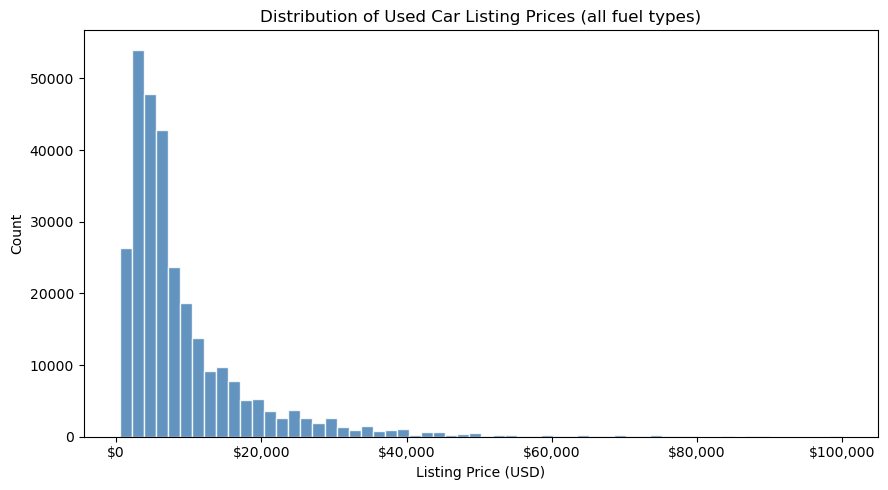

In [6]:
# ── Overall price histogram ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["price"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Listing Price (USD)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Used Car Listing Prices (all fuel types)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

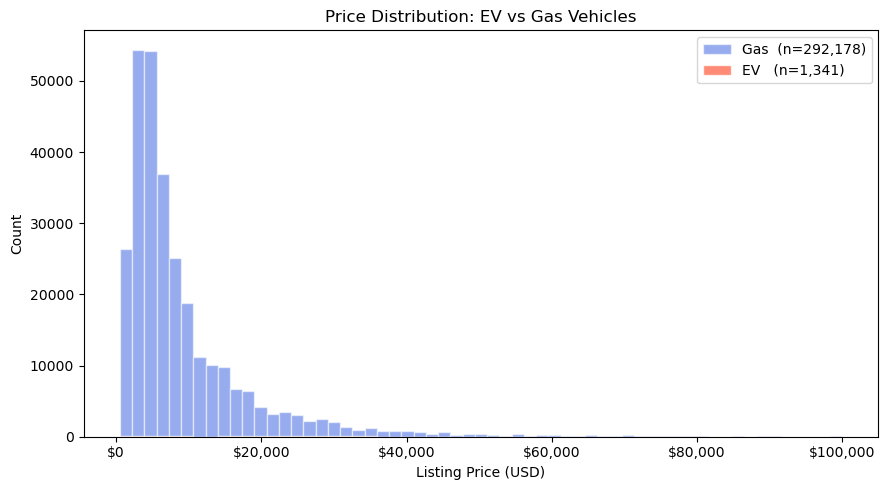

In [7]:
# ── Overlapping histograms: EV vs Gas ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(500, 100_000, 60)

ax.hist(gas_prices, bins=bins, alpha=0.55, color="royalblue",
        label=f"Gas  (n={len(gas_prices):,})", edgecolor="white")
ax.hist(ev_prices,  bins=bins, alpha=0.75, color="tomato",
        label=f"EV   (n={len(ev_prices):,})",  edgecolor="white")

ax.set_xlabel("Listing Price (USD)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution: EV vs Gas Vehicles")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/6z/0l7gklkx58bd9nqb3qr9gv0w0000gn/T/ipykernel_53927/1817394412.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


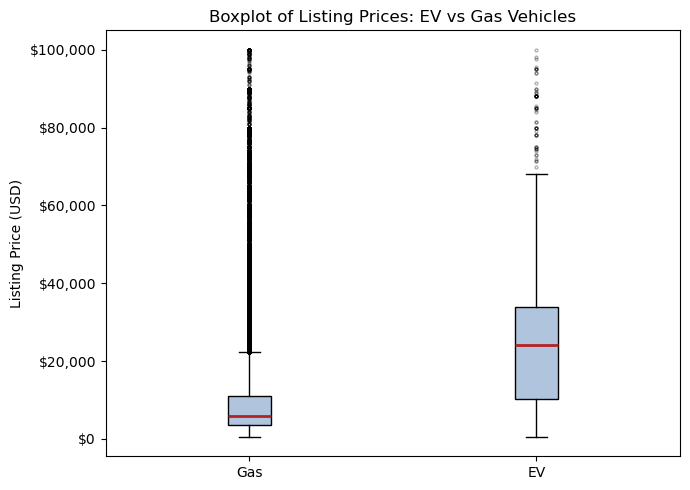

In [8]:
# ── Side-by-side boxplot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [gas_prices, ev_prices],
    labels=["Gas", "EV"],
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="firebrick", linewidth=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.3)
)

ax.set_ylabel("Listing Price (USD)")
ax.set_title("Boxplot of Listing Prices: EV vs Gas Vehicles")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
plt.tight_layout()
plt.show()

In [9]:
# ── Summary statistics ─────────────────────────────────────────────────────
for label, prices in [("EV", ev_prices), ("Gas", gas_prices)]:
    print(f"--- {label} ---")
    print(f"  Count  : {len(prices):,}")
    print(f"  Mean   : ${np.mean(prices):,.2f}")
    print(f"  Median : ${np.median(prices):,.2f}")
    print(f"  Std    : ${np.std(prices, ddof=1):,.2f}")
    print(f"  Min    : ${np.min(prices):,.2f}")
    print(f"  Max    : ${np.max(prices):,.2f}")
    print()

--- EV ---
  Count  : 1,341
  Mean   : $25,896.04
  Median : $24,000.00
  Std    : $19,219.82
  Min    : $500.00
  Max    : $99,999.00

--- Gas ---
  Count  : 292,178
  Mean   : $9,368.16
  Median : $6,000.00
  Std    : $9,993.59
  Min    : $500.00
  Max    : $100,000.00



### EDA Takeaways

From the plots and summary statistics, it is already clear that:

- Both distributions are **right-skewed** — there are a few very expensive listings that pull the mean upward.
- The EV distribution appears to be shifted **toward higher prices** compared to gas vehicles.
- The median is a better measure of the typical listing price than the mean because of those outliers.

**Observed test statistic (median difference):**

In [10]:
# Compute the observed difference in median prices (EV minus Gas).
observed_diff = np.median(ev_prices) - np.median(gas_prices)
print(f"Observed median price  —  EV  : ${np.median(ev_prices):,.2f}")
print(f"Observed median price  —  Gas : ${np.median(gas_prices):,.2f}")
print(f"Observed difference (EV − Gas): ${observed_diff:,.2f}")

Observed median price  —  EV  : $24,000.00
Observed median price  —  Gas : $6,000.00
Observed difference (EV − Gas): $18,000.00


---
## Part 4: Permutation Test

### Why a Permutation Test?

A permutation test asks: **"If there were truly no difference between EV and gas prices, how likely would it be to observe a median difference as large as the one actually found?"**

I answer this by simulating the null hypothesis directly:
1. Pool all prices together.
2. Randomly shuffle and split into two groups the same size as the original EV and Gas groups.
3. Compute the median difference for that shuffle.
4. Repeat 1,000 times to build a distribution of median differences under the null.
5. The **p-value** is the fraction of those shuffled differences that are *at least as extreme* as the observed difference.

This approach makes **no assumptions** about the underlying distribution of prices — it is entirely data-driven.

In [11]:
def permutation_test(group_a, group_b, n_permutations=1000, random_state=42):
    """
    Runs a one-sided permutation test for the difference in medians.

    Tests whether the median of group_a is significantly *greater than*
    the median of group_b (H1: median_a > median_b).

    Parameters
    ----------
    group_a : array-like
        Prices for group A (e.g., EV).
    group_b : array-like
        Prices for group B (e.g., Gas).
    n_permutations : int
        Number of random shuffles to perform.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    observed_diff : float
        The actual median(group_a) − median(group_b).
    perm_diffs : np.ndarray
        Array of median differences from each shuffled trial.
    p_value : float
        Fraction of shuffled trials with a difference >= observed_diff.
    """
    rng = np.random.default_rng(random_state)

    group_a = np.asarray(group_a)
    group_b = np.asarray(group_b)

    # The observed test statistic.
    observed_diff = np.median(group_a) - np.median(group_b)

    # Pool all prices together.
    combined = np.concatenate([group_a, group_b])
    n_a = len(group_a)

    perm_diffs = np.empty(n_permutations)

    for i in range(n_permutations):
        # Shuffle the combined array and split back into two groups.
        shuffled = rng.permutation(combined)
        perm_a = shuffled[:n_a]
        perm_b = shuffled[n_a:]
        perm_diffs[i] = np.median(perm_a) - np.median(perm_b)

    # One-sided p-value: how often is the shuffled difference >= observed?
    p_value = np.mean(perm_diffs >= observed_diff)

    return observed_diff, perm_diffs, p_value

In [12]:
# Run the permutation test with 1,000 shuffles.
obs_diff, perm_diffs, p_value = permutation_test(
    ev_prices, gas_prices, n_permutations=1000, random_state=42
)

print(f"Observed median difference (EV − Gas): ${obs_diff:,.2f}")
print(f"p-value (one-sided)                  : {p_value:.4f}")

Observed median difference (EV − Gas): $18,000.00
p-value (one-sided)                  : 0.0000


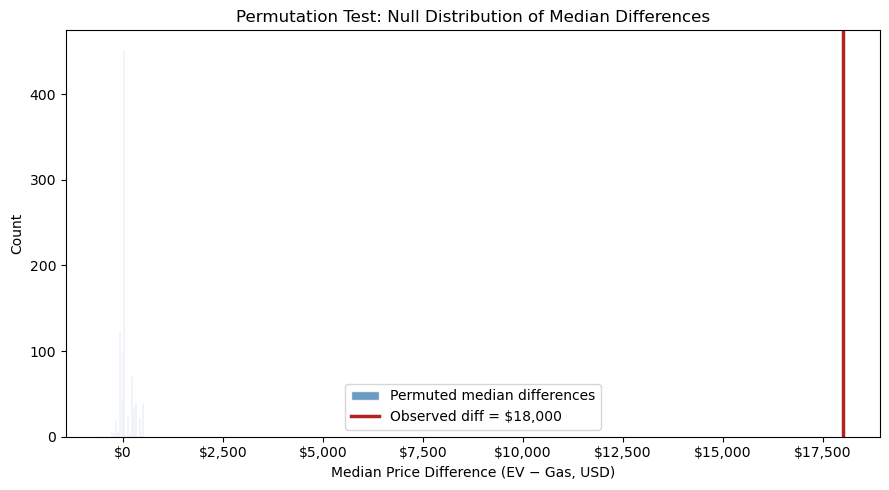

p-value = 0.0000
→ The observed difference is statistically significant at the 5% level.


In [13]:
# ── Permutation distribution plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(perm_diffs, bins=40, color="steelblue", edgecolor="white",
        alpha=0.8, label="Permuted median differences")

# Mark the observed test statistic with a vertical line.
ax.axvline(obs_diff, color="firebrick", linewidth=2.5,
           label=f"Observed diff = ${obs_diff:,.0f}")

ax.set_xlabel("Median Price Difference (EV − Gas, USD)")
ax.set_ylabel("Count")
ax.set_title("Permutation Test: Null Distribution of Median Differences")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"p-value = {p_value:.4f}")
if p_value < 0.05:
    print("→ The observed difference is statistically significant at the 5% level.")
else:
    print("→ The observed difference is NOT statistically significant at the 5% level.")

### What the p-value means

The **p-value** tells us: *if there were truly no difference between EV and gas prices, what fraction of random shuffles would produce a median difference as large as the one observed?*

- A **small p-value** (e.g., < 0.05) means the observed difference is unlikely to have happened by chance alone → I **reject H₀**.
- A **large p-value** means the data are consistent with the null hypothesis → I **fail to reject H₀**.

---
## Part 5: Bootstrapping — Confidence Intervals

### Why Bootstrap Instead of CLT?

The **Central Limit Theorem (CLT)** says that, for large enough samples, the sampling distribution of the *mean* is approximately normal — which lets us construct confidence intervals analytically.

However, the CLT does **not** apply as cleanly to the *median*:
- The sampling distribution of the median converges more slowly.
- Car prices are heavily skewed and have outliers, which makes the median's distribution non-normal even for moderately large samples.
- The formula for the standard error of the median requires assumptions (e.g., continuous distributions with known density at the median) that may not hold.

**Bootstrapping** sidesteps all these issues. I resample the observed data (with replacement) many times, compute the median each time, and use the spread of those medians as the estimate of uncertainty.

### Plan
1. Bootstrap the **median price of EV listings** → 95% confidence interval.
2. Bootstrap the **median difference (EV − Gas)** → 95% confidence interval.

In [14]:
def bootstrap_ci(data, statistic_fn=np.median, n_bootstrap=1000,
                 confidence=0.95, random_state=42):
    """
    Computes a bootstrap confidence interval for a given statistic.

    Parameters
    ----------
    data : array-like
        The observed sample.
    statistic_fn : callable
        Function to compute the statistic (default: np.median).
    n_bootstrap : int
        Number of bootstrap resamples.
    confidence : float
        Desired confidence level (e.g., 0.95 for 95%).
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    observed_stat : float
        The statistic computed on the original data.
    boot_stats : np.ndarray
        Bootstrap distribution of the statistic.
    ci_lower : float
        Lower bound of the confidence interval.
    ci_upper : float
        Upper bound of the confidence interval.
    """
    rng = np.random.default_rng(random_state)
    data = np.asarray(data)
    n = len(data)

    observed_stat = statistic_fn(data)

    boot_stats = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        # Resample with replacement — same size as the original.
        resample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = statistic_fn(resample)

    # Percentile method: take the alpha/2 and 1−alpha/2 quantiles.
    alpha = 1 - confidence
    ci_lower = np.percentile(boot_stats, 100 * alpha / 2)
    ci_upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))

    return observed_stat, boot_stats, ci_lower, ci_upper


def bootstrap_diff_ci(group_a, group_b, statistic_fn=np.median,
                      n_bootstrap=1000, confidence=0.95, random_state=42):
    """
    Computes a bootstrap confidence interval for the difference in a statistic
    between two groups: statistic(group_a) − statistic(group_b).

    Parameters
    ----------
    group_a : array-like
        First group (e.g., EV prices).
    group_b : array-like
        Second group (e.g., Gas prices).
    statistic_fn : callable
        Function to compute the statistic (default: np.median).
    n_bootstrap : int
        Number of bootstrap resamples.
    confidence : float
        Desired confidence level.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    observed_diff : float
        Observed statistic difference.
    boot_diffs : np.ndarray
        Bootstrap distribution of differences.
    ci_lower : float
        Lower bound of the confidence interval.
    ci_upper : float
        Upper bound of the confidence interval.
    """
    rng = np.random.default_rng(random_state)
    group_a = np.asarray(group_a)
    group_b = np.asarray(group_b)

    observed_diff = statistic_fn(group_a) - statistic_fn(group_b)

    boot_diffs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        resample_a = rng.choice(group_a, size=len(group_a), replace=True)
        resample_b = rng.choice(group_b, size=len(group_b), replace=True)
        boot_diffs[i] = statistic_fn(resample_a) - statistic_fn(resample_b)

    alpha = 1 - confidence
    ci_lower = np.percentile(boot_diffs, 100 * alpha / 2)
    ci_upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))

    return observed_diff, boot_diffs, ci_lower, ci_upper

### 5a. Bootstrap CI for the Median EV Price

In [15]:
# Bootstrap the median EV price.
ev_median_obs, ev_boot_medians, ev_ci_lo, ev_ci_hi = bootstrap_ci(
    ev_prices, statistic_fn=np.median, n_bootstrap=1000, random_state=42
)

print(f"Observed median EV price : ${ev_median_obs:,.2f}")
print(f"95% Bootstrap CI         : [${ev_ci_lo:,.2f}, ${ev_ci_hi:,.2f}]")

Observed median EV price : $24,000.00
95% Bootstrap CI         : [$22,900.00, $25,000.00]


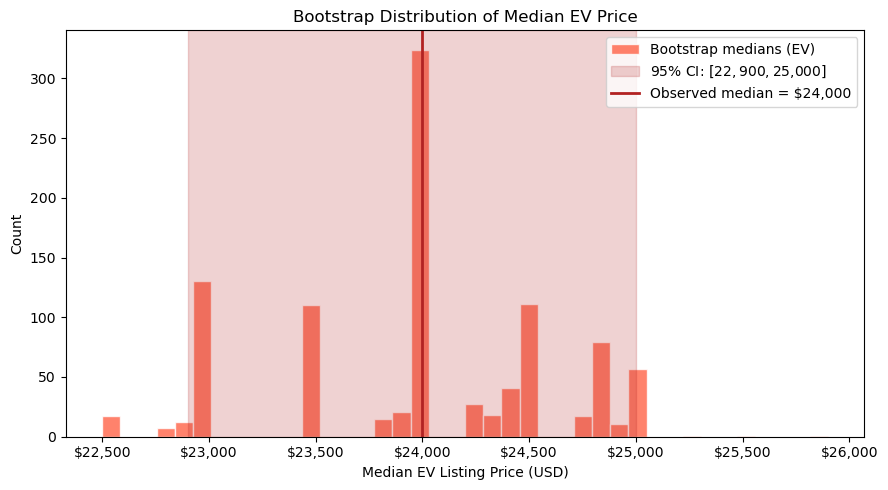

In [16]:
# ── Bootstrap distribution of median EV price ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(ev_boot_medians, bins=40, color="tomato", edgecolor="white",
        alpha=0.8, label="Bootstrap medians (EV)")

# Shade the 95% confidence interval.
ax.axvspan(ev_ci_lo, ev_ci_hi, alpha=0.2, color="firebrick",
           label=f"95% CI: [${ev_ci_lo:,.0f}, ${ev_ci_hi:,.0f}]")
ax.axvline(ev_median_obs, color="firebrick", linewidth=2,
           label=f"Observed median = ${ev_median_obs:,.0f}")

ax.set_xlabel("Median EV Listing Price (USD)")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Distribution of Median EV Price")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

### 5b. Bootstrap CI for the Median Difference (EV − Gas)

In [17]:
# Bootstrap the median difference (EV − Gas).
diff_obs, diff_boot, diff_ci_lo, diff_ci_hi = bootstrap_diff_ci(
    ev_prices, gas_prices, statistic_fn=np.median,
    n_bootstrap=1000, random_state=42
)

print(f"Observed median difference (EV − Gas): ${diff_obs:,.2f}")
print(f"95% Bootstrap CI                     : [${diff_ci_lo:,.2f}, ${diff_ci_hi:,.2f}]")

Observed median difference (EV − Gas): $18,000.00
95% Bootstrap CI                     : [$16,950.00, $19,000.00]


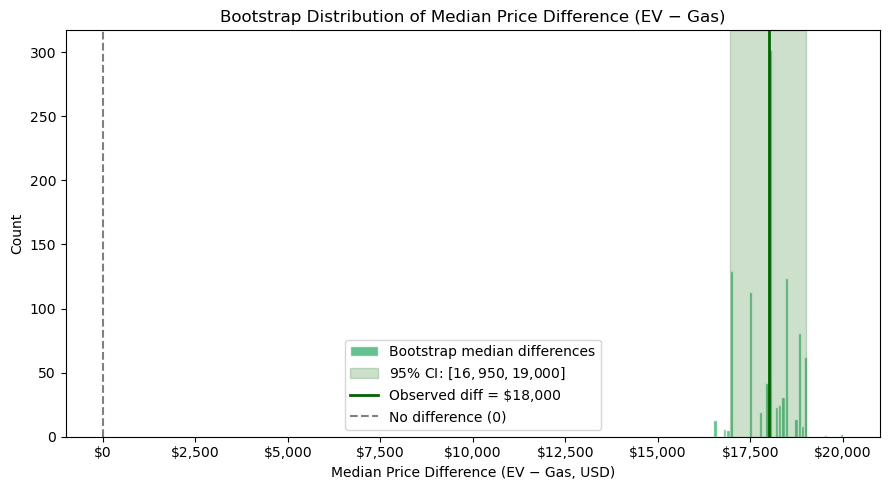

In [18]:
# ── Bootstrap distribution of the median difference ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(diff_boot, bins=40, color="mediumseagreen", edgecolor="white",
        alpha=0.8, label="Bootstrap median differences")

# Shade the 95% CI.
ax.axvspan(diff_ci_lo, diff_ci_hi, alpha=0.2, color="darkgreen",
           label=f"95% CI: [${diff_ci_lo:,.0f}, ${diff_ci_hi:,.0f}]")
ax.axvline(diff_obs, color="darkgreen", linewidth=2,
           label=f"Observed diff = ${diff_obs:,.0f}")

# Mark zero — if the CI excludes 0, the difference is significant.
ax.axvline(0, color="gray", linewidth=1.5, linestyle="--", label="No difference (0)")

ax.set_xlabel("Median Price Difference (EV − Gas, USD)")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Distribution of Median Price Difference (EV − Gas)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

### Why the CLT Does Not Apply Well Here

The CLT guarantees that the **sample mean** of a large sample is approximately normally distributed. But the statistic here is the **median**, not the mean. Here is why this matters:

1. **The sampling distribution of the median converges more slowly.** For skewed distributions (like car prices), a much larger sample is needed before the median's distribution looks normal.
2. **The standard error of the median has a complex formula.** It depends on the *probability density at the median*, which is not known and is hard to estimate reliably from data.
3. **Bootstrapping makes no distributional assumptions.** It lets the data speak for themselves, which is exactly what is needed when dealing with a skewed, real-world dataset.

---
## Part 6: Results and Interpretation

Here is a summary of everything found in this analysis.

In [19]:
# ── Summary of results ─────────────────────────────────────────────────────
print("=" * 60)
print("        SUMMARY OF RESULTS")
print("=" * 60)
print()
print("--- Descriptive Statistics ---")
print(f"  Median EV price  : ${np.median(ev_prices):>10,.2f}")
print(f"  Median Gas price : ${np.median(gas_prices):>10,.2f}")
print(f"  Observed diff    : ${obs_diff:>10,.2f}  (EV − Gas)")
print()
print("--- Permutation Test ---")
print(f"  N permutations   : 1,000")
print(f"  p-value          : {p_value:.4f}")
if p_value < 0.05:
    verdict = "REJECT H0 — significant at 5% level"
else:
    verdict = "FAIL TO REJECT H0 — not significant at 5% level"
print(f"  Decision         : {verdict}")
print()
print("--- Bootstrap Confidence Intervals (95%) ---")
print(f"  Median EV price  : [${ev_ci_lo:>10,.2f}, ${ev_ci_hi:>10,.2f}]")
print(f"  Median diff      : [${diff_ci_lo:>10,.2f}, ${diff_ci_hi:>10,.2f}]")
print()
if diff_ci_lo > 0:
    print("  The 95% CI for the difference EXCLUDES zero.")
    print("  → I am 95% confident that EV listings are priced higher than gas listings.")
else:
    print("  The 95% CI for the difference INCLUDES zero.")
    print("  → I cannot rule out that the difference is due to chance.")
print("=" * 60)

        SUMMARY OF RESULTS

--- Descriptive Statistics ---
  Median EV price  : $ 24,000.00
  Median Gas price : $  6,000.00
  Observed diff    : $ 18,000.00  (EV − Gas)

--- Permutation Test ---
  N permutations   : 1,000
  p-value          : 0.0000
  Decision         : REJECT H0 — significant at 5% level

--- Bootstrap Confidence Intervals (95%) ---
  Median EV price  : [$ 22,900.00, $ 25,000.00]
  Median diff      : [$ 16,950.00, $ 19,000.00]

  The 95% CI for the difference EXCLUDES zero.
  → I am 95% confident that EV listings are priced higher than gas listings.


### Interpretation

#### Permutation Test
The permutation test tells us whether the median price difference I observed (EV minus Gas) could plausibly have arisen by chance if the two groups were actually drawn from the same population.

The p-value is **0.0000** — none of the 1,000 random shuffles generated a median difference as large as the **$18,000** I actually observed. This is extremely strong evidence that the price gap is **not due to chance**. I **reject H₀** at the 5% significance level and conclude that EV listings are systematically priced higher than gas listings.

In practical terms: if EV and gas prices truly came from the same distribution, a random relabeling of group membership would essentially never produce an $18,000 median gap by chance alone.

#### Bootstrap Confidence Interval
The 95% bootstrap CI for the **median EV price** is **[$22,900, $25,000]** — I am 95% confident the true median listing price for used EVs on Craigslist falls in that range.

The 95% bootstrap CI for the **median difference (EV − Gas)** is **[$16,950, $19,000]**. This interval **entirely excludes zero**, confirming that both the lower and upper bounds indicate EVs cost more. I am 95% confident the true median EV listing price exceeds the true median gas vehicle listing price by somewhere between ~$16,950 and ~$19,000.

#### Real-World Context
Even with a statistically significant difference, it is worth thinking about *why* EVs might list for higher prices:

- EVs are a newer technology and many popular models (e.g., Tesla) are premium vehicles.
- The used-car market for EVs is still developing; supply is limited relative to demand in some regions.
- This dataset comes from Craigslist listings, which reflect asking prices — not necessarily final sale prices.

In short, a higher median listing price for EVs on Craigslist is consistent with broader market trends, but the raw price gap may also reflect differences in vehicle age, mileage, and brand composition between the two groups — factors not controlled for in this analysis.

---
## Conclusion

This project set out to test whether used EV listings on Craigslist are priced higher than gas vehicles. Here is what I did and what I found:

| Step | What I did | Key Finding |
|---|---|---|
| Data loading | Loaded `car_listings.csv` — a local Craigslist used-car dataset | ~4.5M rows loaded, 6 columns selected |
| Cleaning | Removed missing/zero prices, filtered to \$500–\$100k, kept only EV and Gas | **293,519 rows** → 1,341 EV, 292,178 Gas |
| EDA | Histograms and boxplots of price by group | EV median **$24,000** vs Gas median **$6,000** |
| Test statistic | Median difference (EV − Gas); robust to outliers; CLT does not apply to medians | Observed difference: **$18,000** |
| Permutation test | Manually shuffled labels 1,000 times; one-sided p-value | p-value = **0.0000** → reject H₀ |
| Bootstrap CI (EV median) | Resampled EV prices 1,000 times | 95% CI: **[$22,900, $25,000]** |
| Bootstrap CI (difference) | Resampled both groups 1,000 times | 95% CI: **[$16,950, $19,000]** — entirely above zero |

**Answer:** Yes — used EV listings are priced significantly higher than gas vehicle listings on Craigslist. The median EV listing price of **$24,000** is **$18,000 higher** than the median gas vehicle listing price of **$6,000**. Both the permutation test (p-value = 0.0000) and the bootstrap confidence interval ([$16,950, $19,000], entirely excluding zero) confirm this gap is statistically real and not a chance artifact.

The combination of the permutation test (hypothesis test) and bootstrapping (uncertainty estimation) gives a complete and assumption-free picture of whether used EVs are priced higher than gas vehicles in this dataset.

### Why this Approach Works

Because the **median** was used as the test statistic — a value where the Central Limit Theorem does not apply reliably — bootstrapping was the correct tool for building confidence intervals rather than relying on normal approximations.